In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

clean = pd.read_csv ('/content/drive/MyDrive/FYP/Clean_Dataset.csv')
eco = pd.read_csv ('/content/drive/MyDrive/FYP/economy.csv')
bus = pd.read_csv ('/content/drive/MyDrive/FYP/business.csv')

print(clean.info())
print(eco.info())
print(bus.info())
print(clean.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtyp

In [3]:
clean.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [4]:
eco.drop(columns=[ 'ch_code', 'num_code', 'arr_time'], inplace=True)
bus.drop(columns=[ 'ch_code', 'num_code', 'arr_time'], inplace=True)
clean.drop(columns=['Unnamed: 0', 'flight', 'arrival_time'], inplace=True)

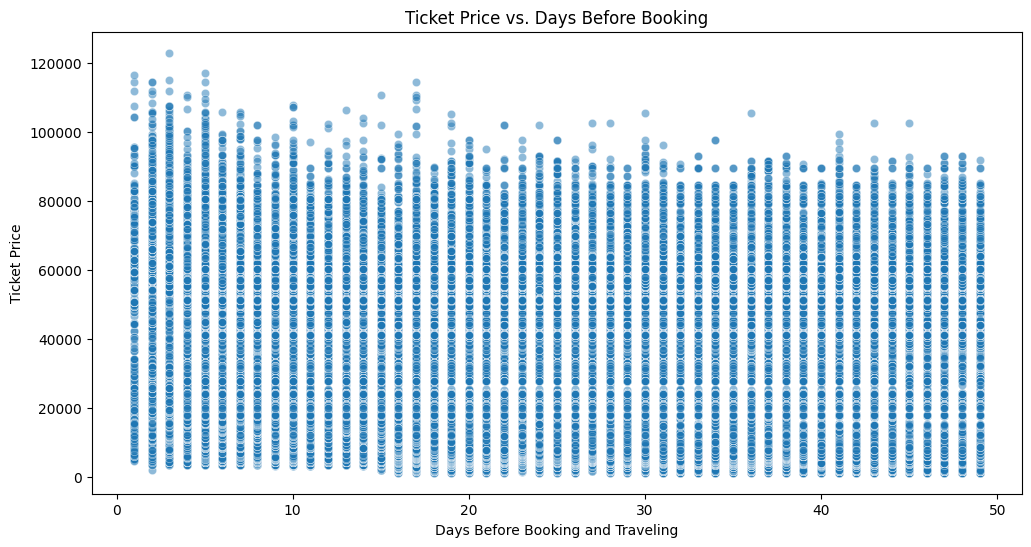

In [5]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='days_left', y='price', data=clean, alpha=0.5)
plt.title('Ticket Price vs. Days Before Booking')
plt.xlabel('Days Before Booking and Traveling')
plt.ylabel('Ticket Price')
plt.show()

<ipython-input-6-c951d81bb7bf>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = clean.groupby('booking_bins')['price'].mean().reset_index()


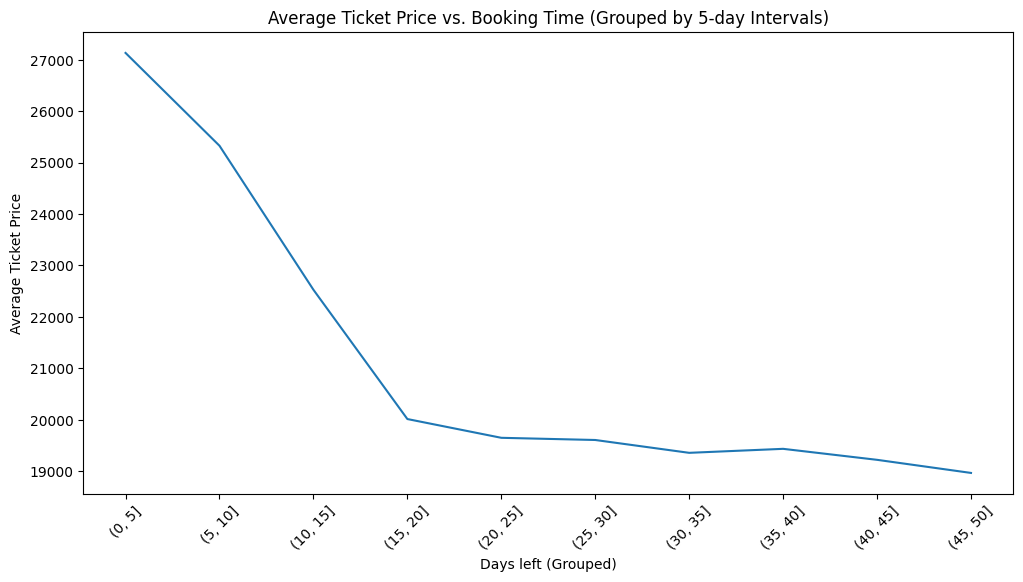

In [6]:

# Create bins (e.g., group every 5 days)
bin_edges = np.arange(0, clean['days_left'].max() + 5, 5)
clean['booking_bins'] = pd.cut(clean['days_left'], bins=bin_edges)

# Aggregate the average price per bin
grouped_data = clean.groupby('booking_bins')['price'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=grouped_data['booking_bins'].astype(str), y=grouped_data['price'])
plt.xticks(rotation=45)
plt.title('Average Ticket Price vs. Booking Time (Grouped by 5-day Intervals)')
plt.xlabel('Days left (Grouped)')
plt.ylabel('Average Ticket Price')


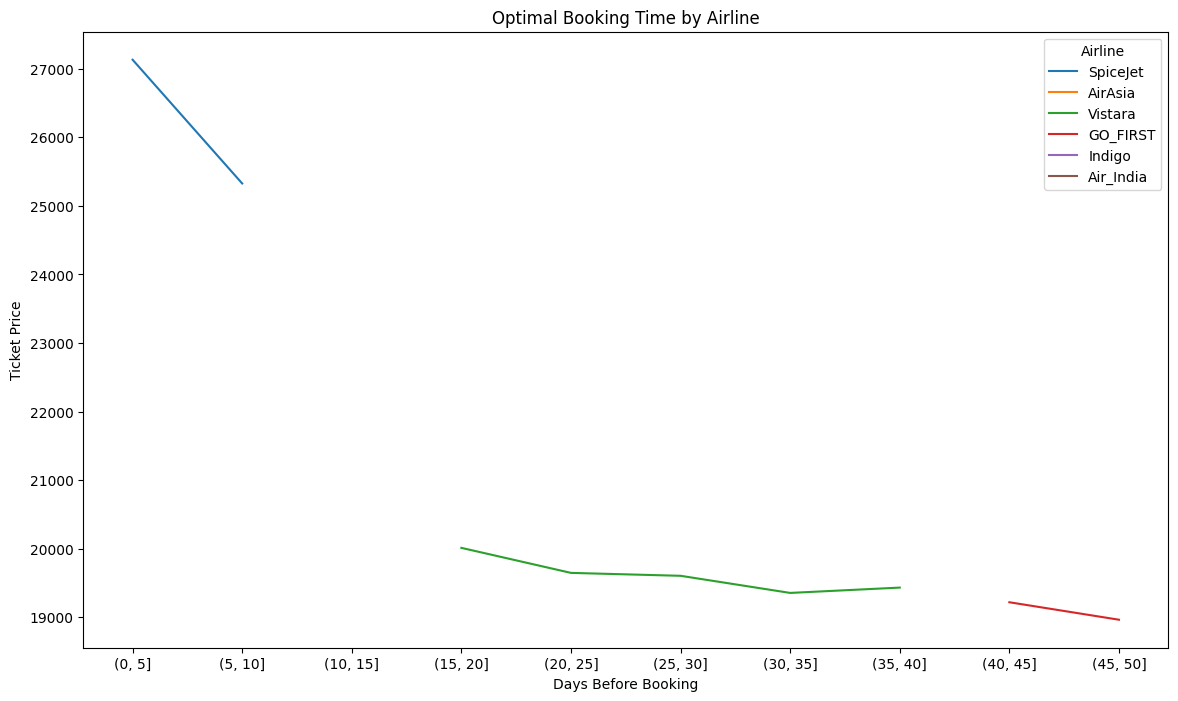

In [8]:
plt.figure(figsize=(14, 8))
sns.lineplot(x=grouped_data['booking_bins'].astype(str), y=grouped_data['price'], hue='airline', data=clean)
plt.title('Optimal Booking Time by Airline')
plt.xlabel('Days Before Booking')
plt.ylabel('Ticket Price')
plt.legend(title='Airline')
plt.show()



<ipython-input-9-919cf2c04dcd>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='days_left', y='price', hue='airline', data=clean, ci=None) # Removed binning, using actual days_left


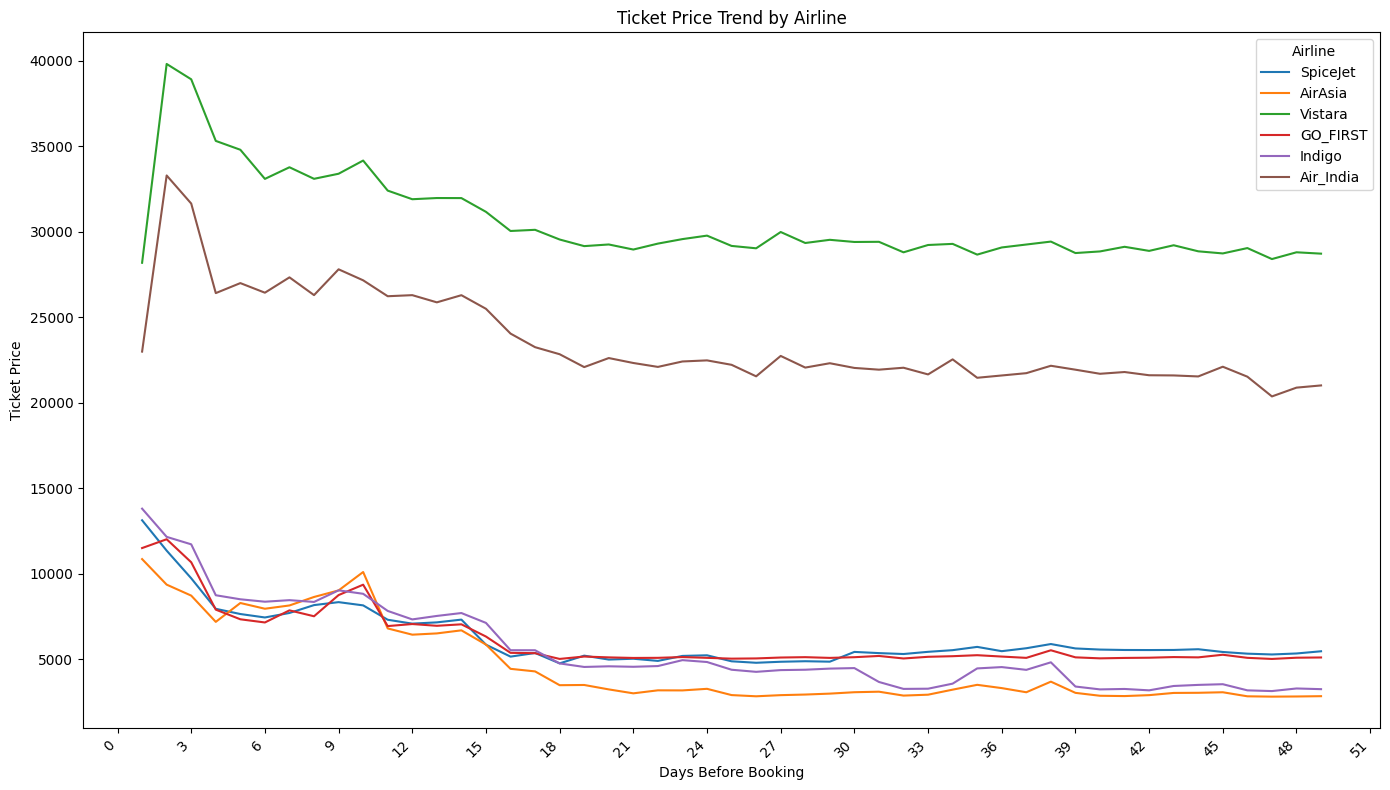

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.lineplot(x='days_left', y='price', hue='airline', data=clean, ci=None)
plt.title('Ticket Price Trend by Airline')
plt.xlabel('Days Before Booking')
plt.ylabel('Ticket Price')
plt.legend(title='Airline')


plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()
